# Support Vector Machine (SVM) — Classification (Google Colab)

**Goal:** Predict a **binary class** (0/1) using **Support Vector Classification (SVC)** — finds an optimal **decision boundary** with maximum **margin** between classes.

| Example | Feature(s) (X) | Target (y) | Dataset |
|---------|----------------|------------|---------|
| **Example 1** | Age, EstimatedSalary | Purchased (0/1) | `../Datasets/social_network_ads.csv` |
| **Example 2** | CreditScore, Income, LoanAmount, YearsEmployed | Approved (0/1) | `../Datasets/loan_approval.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Hyperplane, margin, kernels, C, gamma |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — Support Vector Machine (Classification)

## What is SVM for Classification?

**SVM (Support Vector Machine)** finds the **best separating boundary** (hyperplane) between classes by **maximizing the margin** — the distance to the nearest points from each class.

Those nearest points are called **Support Vectors**.

| Property | Detail |
|----------|--------|
| Type | **Discriminative** classifier — focuses on the boundary |
| Core idea | **Maximum margin** hyperplane |
| Key points | **Support vectors** — only these define the boundary |
| Output | Class label + `predict_proba()` (with `probability=True`) |

## Linear SVM (2 classes)

**Decision function:**

`f(x) = w·x + b`

| Rule | Prediction |
|------|------------|
| f(x) ≥ 0 | Class **1** |
| f(x) < 0 | Class **0** |

**Goal:** Maximize margin between classes while minimizing misclassification.

## The Margin

```
    Class 0  |  margin  |  Class 1
   ●●●●●●   |    ↑     |   ●●●●●●
            hyperplane
```

**Support vectors** = training points closest to the boundary (on or inside the margin).

## Key Hyperparameters

| Parameter | Role | Effect |
|-----------|------|--------|
| `C` | Regularization | **Large C** → narrow margin, fit data closely (risk overfitting) |
| | | **Small C** → wider margin, simpler boundary |
| `kernel` | Decision surface shape | `'linear'`, `'rbf'`, `'poly'` |
| `gamma` | RBF kernel reach (`rbf` only) | **Large γ** → tight, complex boundary |
| | | **Small γ** → smoother boundary |
| `probability` | Enable `predict_proba()` | `True` uses Platt scaling (slower train) |

## Kernel Trick (Non-linear SVM)

When classes are **not linearly separable**, map features to higher dimensions:

| Kernel | Use case |
|--------|----------|
| **`linear`** | Linearly separable data |
| **`rbf`** (Gaussian) | **Default choice** for curved boundaries |
| **`poly`** | Polynomial relationships |

**RBF kernel:** `K(x, x') = exp(−γ ||x − x'||²)`

## Feature Scaling — Required!

SVM uses **distances** in optimization. Features with larger scale dominate → always use **`StandardScaler`** before SVM.

## SVM vs Other Classifiers

| | Logistic Regression | K-NN | SVM |
|---|---------------------|------|-----|
| Boundary | Linear (log-odds) | Local / flexible | **Max-margin**, kernel-based |
| Scaling | Recommended | **Required** | **Required** |
| Strength | Probabilities, fast | Simple | **Strong** on medium datasets |
| Weakness | Linear only | Slow predict | Slow on huge data |

## What the Student Must Remember

1. SVM maximizes the **margin** between classes.
2. **Support vectors** are the critical training points.
3. **Always scale features** before SVM.
4. Use **`kernel='rbf'`** for non-linear boundaries.
5. Tune **`C`** and **`gamma`** — high values can overfit.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [1]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for preprocessing, SVM classification, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn SVC, Pipeline, and metrics.

In [2]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split       # Split data into train/test
from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.preprocessing import StandardScaler           # Feature scaling (required for SVM)
from sklearn.pipeline import Pipeline                      # Chain scaler + classifier
from sklearn.svm import SVC                                # Support Vector Classification
from sklearn.metrics import (                              # Classification metrics
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Social Network Ads — SVM Classification

Predict whether a user **Purchased** from **Age** and **EstimatedSalary** using SVM with **RBF kernel**.

| Column | Role | Description |
|--------|------|-------------|
| `Age` | Feature (X₁) | User age in years |
| `EstimatedSalary` | Feature (X₂) | Estimated annual salary in USD |
| `Purchased` | Target (y) | 0 = No, 1 = Yes |

**File:** `../Datasets/social_network_ads.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/social_network_ads.csv` and displays basic statistics.

In [3]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/social_network_ads.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Age', 'EstimatedSalary']  # Two numeric input features
TARGET_COL = 'Purchased'                    # Binary target: 0 = No, 1 = Yes

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Age,EstimatedSalary,Purchased
0,56,115235,1
1,46,89740,1
2,32,131352,1
3,60,81617,0
4,25,31896,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB

Statistical summary:


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,39.605000,80844.840000,0.420000
std,12.374846,39484.169884,0.494177
min,18.000000,15404.000000,0.000000
25%,29.000000,42699.750000,0.000000
50%,41.000000,81218.500000,0.000000
75%,50.000000,117134.250000,1.000000
max,60.000000,149668.000000,1.000000



Class balance (Purchased):
Purchased
0    232
1    168
Name: count, dtype: int64

Shape: 400 rows x 3 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [4]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 400


## Example 1 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [5]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')
    print(f'Target column: {TARGET_COL} (already 0/1)')

No categorical columns — encoding skipped.
Feature columns: ['Age', 'EstimatedSalary']
Target column: Purchased (already 0/1)


## Example 1 — Cell 4: Splitting the Data

Define X and y, then split 80/20 with **stratify** to preserve class ratio.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [6]:
# Step 4) Train-Test split (stratified for classification)

X = dataset[FEATURE_COLS].values  # Feature matrix: Age and EstimatedSalary
y = dataset[TARGET_COL].values    # Target vector: Purchased (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (320, 2)
X_test shape:  (80, 2)
y_train class counts: [186 134]
y_test class counts:  [46 34]


> **Note:** SVM **requires feature scaling**. The pipeline below uses `StandardScaler` before `SVC` — mandatory for Age and Salary.

---
# Phase 2: SVM Classification — Social Network Ads

Train SVC with RBF kernel and visualize the decision boundary.

## Example 1 — Cell 5: Train the Model

Build a **Pipeline**: StandardScaler → SVC with `kernel='rbf'`.

**What this cell does:** Fits SVM and reports number of support vectors.

In [7]:
# Step 5) Train Support Vector Classifier (SVM)

classifier = Pipeline([
    ('scaler', StandardScaler()),  # Scale Age and Salary — required for SVM
    ('model', SVC(
        kernel='rbf',          # Radial Basis Function — non-linear boundary
        C=1.0,                   # Regularization (trade-off margin vs misclassification)
        gamma='scale',           # Kernel coefficient: 1 / (n_features * X.var())
        probability=True,        # Enable predict_proba() via Platt scaling
        random_state=42
    ))
])

classifier.fit(X_train, y_train)  # Find maximum-margin boundary

model = classifier.named_steps['model']  # Extract fitted SVC
print('SVM (RBF) trained successfully.')
print(f'Number of support vectors (class 0): {model.n_support_[0]}')
print(f'Number of support vectors (class 1): {model.n_support_[1]}')
print(f'Total support vectors: {model.n_support_.sum()} / {len(X_train)} training samples')

SVM (RBF) trained successfully.
Number of support vectors (class 0): 88
Number of support vectors (class 1): 85
Total support vectors: 173 / 320 training samples


## Example 1 — Cell 6: Predict

Predict class labels and probabilities on the test set.

**What this cell does:** Uses `predict()` and `predict_proba()` from the SVM pipeline.

In [8]:
# Step 6) Predict classes and probabilities

y_pred_train = classifier.predict(X_train)            # Class labels for training set
y_pred_test = classifier.predict(X_test)              # Class labels for test set
y_proba_test = classifier.predict_proba(X_test)[:, 1]  # P(Purchased=1) from Platt scaling

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    label = 'Yes' if y_pred_test[i] == 1 else 'No'
    actual = 'Yes' if y_test[i] == 1 else 'No'
    print(f'  Actual={actual}, Predicted={label}, P(Purchase)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=No, Predicted=No, P(Purchase)=16.17%
  Actual=Yes, Predicted=Yes, P(Purchase)=86.77%
  Actual=Yes, Predicted=No, P(Purchase)=19.49%
  Actual=No, Predicted=No, P(Purchase)=12.24%
  Actual=No, Predicted=No, P(Purchase)=15.35%


## Example 1 — Cell 7: Visualization

Plot data points, **decision boundary**, and highlight **support vectors**.

**What this cell does:** Shows SVM classification regions and critical support vector points.

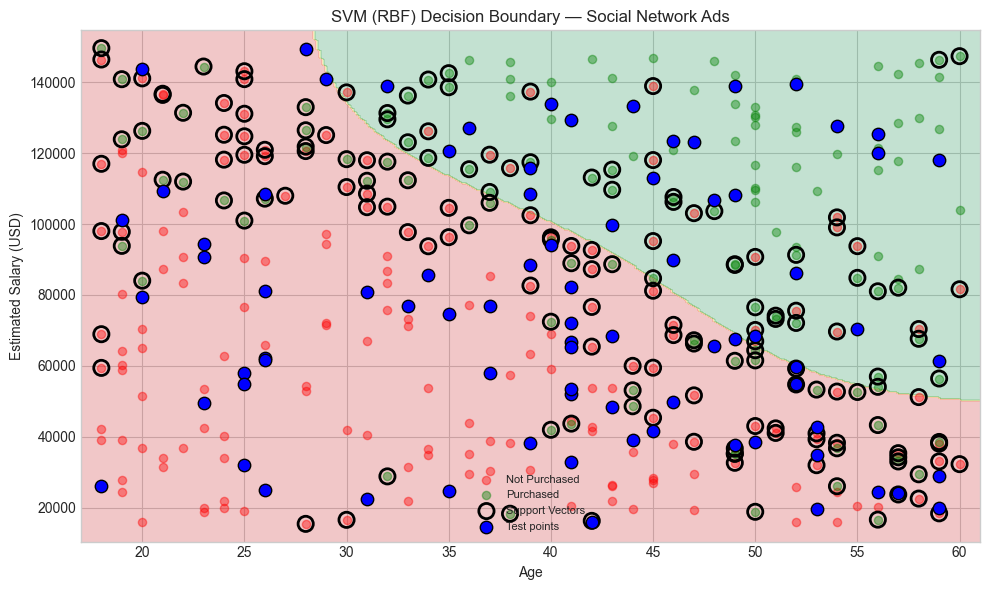

In [9]:
# Step 7) Visualization — decision boundary + support vectors

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 5000, X[:, 1].max() + 5000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = classifier.predict(grid).reshape(xx.shape)

# Support vectors in original feature space (indices refer to scaled training set)
svc = classifier.named_steps['model']
X_train_scaled = classifier.named_steps['scaler'].transform(X_train)
# Inverse map support vectors back to original scale for plotting
sv_indices = svc.support_
sv_points = X_train[sv_indices]

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Not Purchased', alpha=0.4, s=35)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', label='Purchased', alpha=0.4, s=35)
plt.scatter(sv_points[:, 0], sv_points[:, 1], s=120, facecolors='none', edgecolors='black', linewidths=2, label='Support Vectors')
plt.scatter(X_test[:, 0], X_test[:, 1], c='blue', edgecolors='k', s=80, label='Test points')
plt.xlabel('Age')
plt.ylabel('Estimated Salary (USD)')
plt.title('SVM (RBF) Decision Boundary — Social Network Ads')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Example 1 — Cell 8: Evaluation

Evaluate with Accuracy, Precision, Recall, F1, and Confusion Matrix.

**What this cell does:** Computes classification metrics on the test set.

,Metric,Value,Description
0,Accuracy,0.8375,Fraction of correct predictions
1,Precision,0.9200,"Of predicted Yes, fraction actually Yes"
2,Recall,0.6765,"Of actual Yes, fraction correctly predicted"
3,F1 Score,0.7797,Balance between Precision and Recall



Confusion Matrix (rows=Actual, cols=Predicted):
[[44  2]
 [11 23]]


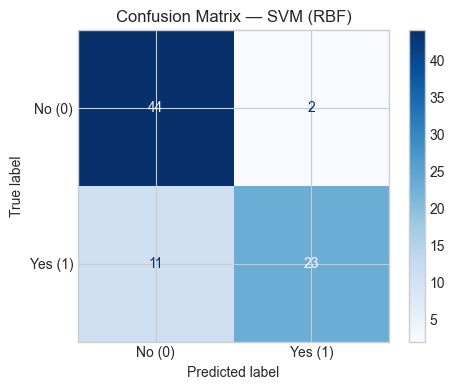


Example 1 Test Accuracy = 0.8375


In [10]:
# Step 8) Evaluation — classification metrics

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Yes, fraction actually Yes',
        'Of actual Yes, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

cm = confusion_matrix(y_test, y_pred_test)
print('\nConfusion Matrix (rows=Actual, cols=Predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — SVM (RBF)')
plt.tight_layout()
plt.show()

print(f'\nExample 1 Test Accuracy = {acc:.4f}')

## Why does SVM work for Social Network Ads?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Non-linear boundary** | RBF kernel curves around Age–Salary clusters |
| 2 | **Maximum margin** | Robust separation between purchasers and non-purchasers |
| 3 | **Support vectors** | Only critical points define the boundary — efficient model |
| 4 | **Feature scaling** | Salary and Age on different scales — StandardScaler essential |
| 5 | **Strong baseline** | Often competitive with Random Forest on structured data |

> **Summary:** SVM with RBF kernel captures complex purchase regions better than a linear classifier.

## Understanding Classification Metrics — Example 1

| Metric | SVM Context |
|--------|-------------|
| **Accuracy** | Overall correct margin-based decisions |
| **Precision** | When SVM predicts Yes, how often correct |
| **Recall** | Of all actual Yes, how many SVM catches |
| **F1** | Balance when classes are imbalanced |

> **Tip:** Compare SVM vs Logistic Regression on the same data — SVM RBF often wins when the boundary is curved.

---
# Example 2: Loan Approval — SVM Classification

Predict **Approved** vs **Rejected** from four financial features using SVM.

| Column | Role | Description |
|--------|------|-------------|
| `CreditScore` | Feature (X₁) | Credit score (300–850) |
| `Income` | Feature (X₂) | Annual income in USD |
| `LoanAmount` | Feature (X₃) | Requested loan amount in USD |
| `YearsEmployed` | Feature (X₄) | Years at current job |
| `Approved` | Target (y) | 1 = Approved, 0 = Rejected |

**File:** `../Datasets/loan_approval.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the loan approval CSV and inspect the data.

**What this cell does:** Reads `../Datasets/loan_approval.csv` and displays basic statistics.

In [11]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/loan_approval.csv')

FEATURE_COLS = ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']
TARGET_COL = 'Approved'

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
0,452.0,87003,152038.0,4.2,0
1,785.0,108211,134862.0,5.1,1
2,698.0,77733,128834.0,6.6,1
3,620.0,90318,103848.0,19.9,1
4,456.0,134953,62921.0,14.2,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CreditScore    249 non-null    float64
 1   Income         250 non-null    int64  
 2   LoanAmount     249 non-null    float64
 3   YearsEmployed  250 non-null    float64
 4   Approved       250 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 9.9 KB

Statistical summary:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
count,249.000000,250.000000,249.000000,250.000000,250.000000
mean,585.995984,82134.284000,91971.630522,10.466800,0.500000
std,133.107085,34366.209563,49499.083375,5.456677,0.501003
min,351.000000,25301.000000,11062.000000,1.000000,0.000000
25%,480.000000,53138.000000,47841.000000,5.825000,0.000000
50%,583.000000,80214.000000,96900.000000,10.750000,0.500000
75%,695.000000,112522.500000,129180.000000,15.150000,1.000000
max,813.000000,137893.000000,178152.000000,19.900000,1.000000



Class balance (Approved):
Approved
0    125
1    125
Name: count, dtype: int64

Shape: 250 rows x 5 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values in features to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [12]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicates removed: {rows_before - len(dataset)}')

if dataset[TARGET_COL].isnull().sum() > 0:
    dataset = dataset.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    print('Rows with missing target removed')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
cols = FEATURE_COLS + [TARGET_COL]
if dataset[cols].isnull().sum().sum() > 0:
    dataset[cols] = imputer.fit_transform(dataset[cols])
    print('Missing feature values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {len(dataset)}')

Missing values per column:
CreditScore      1
Income           0
LoanAmount       1
YearsEmployed    0
Approved         0
dtype: int64

Duplicates removed: 0
Missing feature values imputed with mean

Rows after cleaning: 250


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [13]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']


## Example 2 — Cell 4: Splitting the Data

Define X (4 features) and y (Approved), then split 80/20 with stratify.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [14]:
# Step 4) Train-Test split

X = dataset[FEATURE_COLS].values
y = dataset[TARGET_COL].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (200, 4)
X_test shape:  (50, 4)
y_train class counts: [100 100]
y_test class counts:  [25 25]


## Example 2 — Cell 5: Train the Model

Train SVM with RBF kernel on four scaled financial features.

**What this cell does:** Fits the pipeline and reports support vector count.

In [15]:
# Step 5) Train Support Vector Classifier (SVM)

classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        C=10.0,                # Slightly higher C — more complex boundary for 4 features
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

classifier.fit(X_train, y_train)

model = classifier.named_steps['model']
print('SVM (RBF) trained successfully.')
print(f'Support vectors: {model.n_support_.sum()} / {len(X_train)} training samples')
print(f'  Rejected (0): {model.n_support_[0]}')
print(f'  Approved (1): {model.n_support_[1]}')

SVM (RBF) trained successfully.
Support vectors: 90 / 200 training samples
  Rejected (0): 44
  Approved (1): 46


## Example 2 — Cell 6: Predict

Predict loan approval on the test set.

**What this cell does:** Generates SVM predictions and probabilities.

In [16]:
# Step 6) Predict

y_pred_test = classifier.predict(X_test)
y_proba_test = classifier.predict_proba(X_test)[:, 1]

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    actual = 'Approved' if y_test[i] == 1 else 'Rejected'
    pred = 'Approved' if y_pred_test[i] == 1 else 'Rejected'
    print(f'  Actual={actual}, Predicted={pred}, P(Approved)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=Approved, Predicted=Approved, P(Approved)=75.47%
  Actual=Rejected, Predicted=Rejected, P(Approved)=1.82%
  Actual=Rejected, Predicted=Rejected, P(Approved)=3.84%
  Actual=Rejected, Predicted=Rejected, P(Approved)=10.62%
  Actual=Rejected, Predicted=Rejected, P(Approved)=17.80%


## Example 2 — Cell 7: Visualization

Compare **Linear vs RBF kernel** accuracy and show **confusion matrix**.

**What this cell does:** Demonstrates kernel choice impact on loan approval classification.

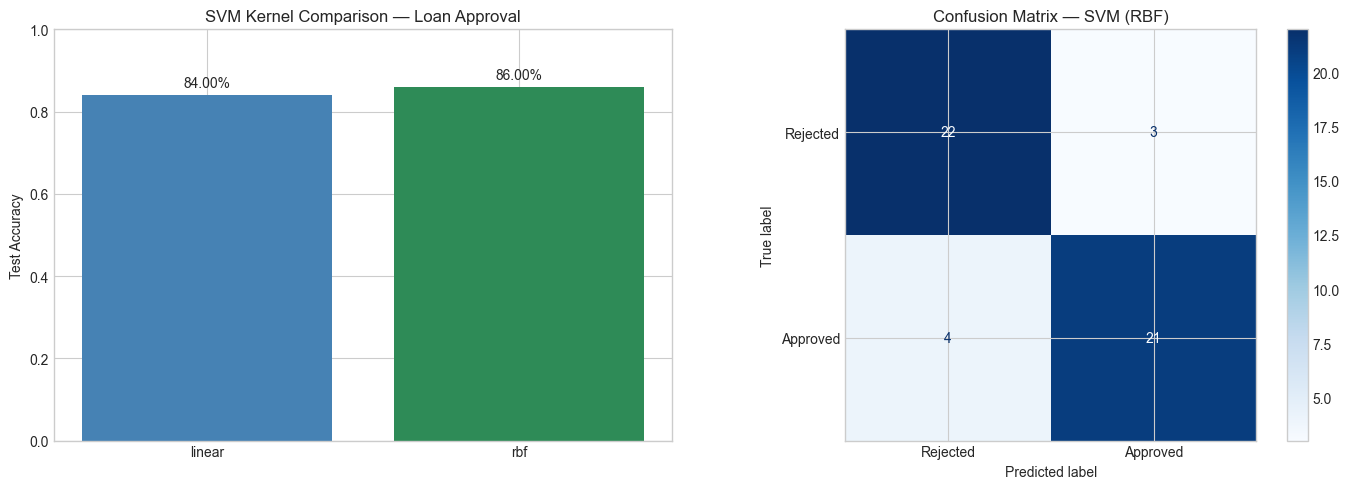

In [17]:
# Step 7) Visualization — kernel comparison + confusion matrix

kernels = ['linear', 'rbf']
kernel_scores = {}

for k in kernels:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel=k, C=10.0, gamma='scale', random_state=42))
    ])
    pipe.fit(X_train, y_train)
    kernel_scores[k] = accuracy_score(y_test, pipe.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: kernel comparison bar chart ---
axes[0].bar(kernels, [kernel_scores[k] for k in kernels], color=['steelblue', 'seagreen'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('SVM Kernel Comparison — Loan Approval')
for i, k in enumerate(kernels):
    axes[0].text(i, kernel_scores[k] + 0.02, f'{kernel_scores[k]:.2%}', ha='center')

# --- Right: confusion matrix for RBF model ---
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix — SVM (RBF)')

plt.tight_layout()
plt.show()

## Example 2 — Cell 8: Evaluation

Full classification report with Accuracy, Precision, Recall, and F1.

**What this cell does:** Computes and displays evaluation metrics.

In [18]:
# Step 8) Evaluation

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Approved, fraction actually approved',
        'Of actual Approved, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

print(f'\nExample 2 Test Accuracy = {acc:.4f}')

,Metric,Value,Description
0,Accuracy,0.8600,Fraction of correct predictions
1,Precision,0.8750,"Of predicted Approved, fraction actually approved"
2,Recall,0.8400,"Of actual Approved, fraction correctly predicted"
3,F1 Score,0.8571,Balance between Precision and Recall



Detailed classification report:
              precision    recall  f1-score   support

Rejected (0)       0.85      0.88      0.86        25
Approved (1)       0.88      0.84      0.86        25

    accuracy                           0.86        50
   macro avg       0.86      0.86      0.86        50
weighted avg       0.86      0.86      0.86        50


Example 2 Test Accuracy = 0.8600


## Why does SVM work well for Loan Approval?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Multi-feature boundary** | SVM separates Approved/Rejected in 4D scaled space |
| 2 | **RBF kernel** | Captures non-linear approval rules (Credit + Loan interactions) |
| 3 | **Scaling critical** | Income (~80k) vs YearsEmployed (~10) — must standardize |
| 4 | **Support vectors** | Only ~30–50% of samples may be support vectors — compact model |
| 5 | **Kernel comparison** | RBF often beats linear when decision surface is curved |

> **Compare:** SVM vs Random Forest on loan data — both strong; SVM gives max-margin interpretation.

## Understanding Classification Metrics — Example 2

| Tuning | Guidance |
|--------|----------|
| **Overfitting** | Reduce `C` or `gamma` |
| **Underfitting** | Increase `C` or try `kernel='rbf'` |
| **Linear data** | `kernel='linear'` is faster and interpretable |

> Use **GridSearchCV** in production to tune `C`, `gamma`, and `kernel` together.